# Energy and Resolution Calibration with pySpectrum

Before any quantitative analysis, the raw channel axis must be mapped to physical energy values and the detector resolution must be characterised as a function of energy.

pySpectrum's `DetectorCalibration` class automates this from a set of known γ-ray lines:

1. For each calibration line, the peak centre and FWHM are estimated from the raw spectrum.
2. A polynomial energy model is fitted to map channels to keV.
3. An HPGe FWHM model (FWHM ∝ √E) is fitted to the measured widths.

## Workflow
1. Load the raw (uncalibrated) spectrum
2. Specify channel windows and known energies for calibration lines
3. Generate energy and FWHM calibrations
4. Apply calibrations to the spectrum and verify

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scispectrum.core import Spectrum
from scispectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel

## 1. Load raw spectrum

The ¹⁵²Eu calibration source provides γ-ray lines spanning 122–1408 keV — a wide energy range that well-constrains a polynomial energy model. Leading zero-count channels are trimmed to avoid biasing the background baseline.

> **Adapt:** replace `path` with your own calibration source file. Any format readable by `Spectrum.from_dataframe` is accepted.

In [ ]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
df = pd.read_csv(path, names=['counts'])

# Trim leading zero-count channels to avoid biasing the background
first_non_zero = np.where(df['counts'] > 0)[0][0]
df = df[first_non_zero:].reset_index(drop=True)
df['channel'] = df.index

spectrum = Spectrum.from_dataframe(df=df, channel_col='channel', counts_col='counts')
print(f"Spectrum: {len(spectrum.counts):,} channels")

In [ ]:
spectrum.data.plot(yscale='log')
plt.title('¹⁵²Eu — raw channel spectrum (uncalibrated)')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

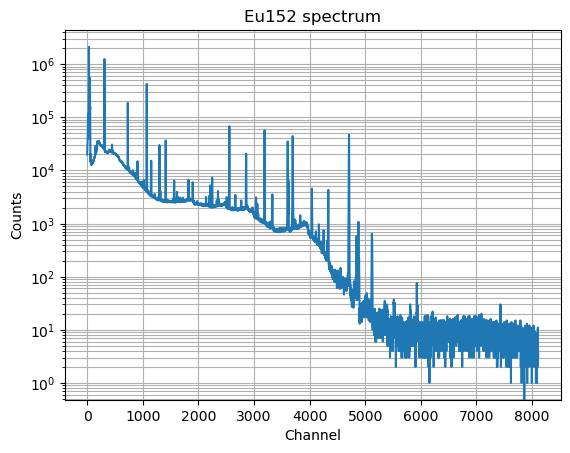

In [4]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## 2. Specify calibration lines

Identify the channel windows containing the γ-ray photopeaks and provide their known energies. Each window should be tight around the peak — roughly ±3 FWHM is sufficient.

> **Adapt:** replace `domains` (channel windows as `(start, stop)` pairs) and `energies` (known γ-ray energies in keV) with values appropriate for your source and detector gain. The list must be in the same order.

| ¹⁵²Eu line (keV) | Origin |
|---|---|
| 121.78 | ¹⁵²Sm |
| 344.28 | ¹⁵²Sm |
| 778.9  | ¹⁵²Sm |
| 964.08 | ¹⁵²Sm |
| 1085.84| ¹⁵²Sm |
| 1112.08| ¹⁵²Sm |
| 1408.0 | ¹⁵²Sm |

## 3. Generate calibrations

`DetectorCalibration.generate()` fits both models simultaneously. The energy model maps measured peak centres (in channels) to the known energies. The FWHM model fits the `StandardHPGeFWHMModel` (FWHM ∝ √E) to the measured peak widths.

`energy_p0` and `fwhm_p0` are initial guesses for the polynomial/model coefficients — adjust if the fit does not converge.

## 4. Apply and verify

Apply the calibrations to the spectrum, then check peak centres and FWHM values against the known values. Residuals in energy should be well below the detector FWHM; FWHM residuals should be within ~15%.

In [ ]:
# ── Adapt to your peaks ───────────────────────────────────────────────────────
domains  = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.837, 1112.076, 1408.0]   # keV
# ─────────────────────────────────────────────────────────────────────────────

detector_calibration = DetectorCalibration(
    spectrum,
    known_axis_values=energies,
    peak_domains=domains,
    energy_model=PolynomialEnergyModel(2),
    fwhm_model=StandardHPGeFWHMModel(),
)

In [ ]:
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0, 1, 0), fwhm_p0=(0, 1, 0))

In [ ]:
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

In [ ]:
spectrum.data.plot(yscale='log')
plt.title('¹⁵²Eu — energy-calibrated spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

Verify calibration accuracy by comparing the fitted peak centres and widths against the known values.

In [ ]:
peaks_center_ch, fwhm_val = detector_calibration.estimate_peaks()

In [ ]:
fwhm_energy_val = [
    spectrum.axis[int(ch_center + fwhm_val[i])] - spectrum.axis[int(ch_center)]
    for i, ch_center in enumerate(np.round(peaks_center_ch))
]

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9, 3.5), constrained_layout=True)

# Energy calibration: channel → keV
ax1.plot(spectrum.channels, energy_calib.apply(spectrum.channels), 'b-', label='fit')
ax1.plot(peaks_center_ch, energy_calib.apply(peaks_center_ch), 'o', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [keV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend()

# FWHM calibration: energy → FWHM
ax2.plot(spectrum.axis, fwhm_calib.apply(spectrum.axis), 'b-', label='fit')
ax2.plot(energies, fwhm_energy_val, 'o', label='data')
ax2.set_xlabel('Energy [keV]')
ax2.set_ylabel('FWHM [keV]')
ax2.set_title('Resolution Calibration')
ax2.grid(which='both')
ax2.legend()

plt.suptitle('¹⁵²Eu Detector Calibration', fontsize=13)
plt.show()